<a href="https://colab.research.google.com/github/arushnab/Genrify/blob/main/notebooks/Initial_Lyrics_Based_Music_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import os
os.listdir("/content/drive/MyDrive/Colab Notebooks/")
import nbformat

path = "/content/drive/MyDrive/Colab Notebooks/Initial Lyrics-Based Music Genre Classification.ipynb"
nb = nbformat.read(path, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, path)

#Data Loading

###Load Dataset

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/APS360_Project/archive/songs.csv')
print(df.columns.tolist())
print(df.shape)
print(df['genre'].value_counts())

Mounted at /content/drive
['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres']
(550622, 24)
genre
Rock          197168
Pop            72539
Electronic     69755
Folk           50843
Country        46076
Hip-Hop        41745
R&B            27337
Jazz           17010
Blues          15976
Classical      12173
Name: count, dtype: int64


##Modify Dataframe and Balance Classes

In [ ]:
import pandas as pd

# Keeping only necessary columns
df = df[['name', 'artists', 'lyrics', 'genre']]

# Drop all songs with missing or very short lyrics (less than 100 characters)
df = df.dropna(subset=['lyrics'])
df = df[df['lyrics'].str.len() >= 100]

# Lowercase and normalize whitespace
df['lyrics'] = df['lyrics'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()

# Balance datafram to 1000 samples per genre
df_balanced = (
    df.groupby('genre')
    .apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))
    .reset_index(drop=True)
)

print(df_balanced['genre'].value_counts())
print(df_balanced.shape)

genre
Blues         1000
Classical     1000
Country       1000
Electronic    1000
Folk          1000
Hip-Hop       1000
Jazz          1000
Pop           1000
R&B           1000
Rock          1000
Name: count, dtype: int64
(10000, 4)


/tmp/ipykernel_2896/1742683375.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))


## Build Train/Test/Val Split

Train: 7011, Val: 1503, Test: 1486


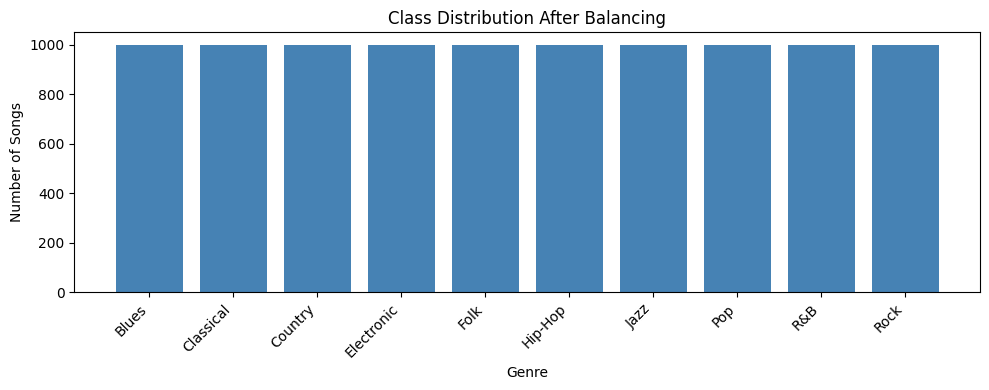

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Get unique artists and split them
artists = df_balanced['artists'].unique()
artists_train, artists_temp = train_test_split(artists, test_size=0.30, random_state=42)
artists_val, artists_test = train_test_split(artists_temp, test_size=0.50, random_state=42)

# Assign splits based on artist
train_df = df_balanced[df_balanced['artists'].isin(artists_train)].reset_index(drop=True)
val_df   = df_balanced[df_balanced['artists'].isin(artists_val)].reset_index(drop=True)
test_df  = df_balanced[df_balanced['artists'].isin(artists_test)].reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Plot class distribution
fig, ax = plt.subplots(figsize=(10, 4))
genre_counts = df_balanced['genre'].value_counts().sort_index()
ax.bar(genre_counts.index, genre_counts.values, color='steelblue')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Songs')
ax.set_title('Class Distribution After Balancing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [ ]:
# Example of cleaned lyrics from each split
example = train_df.groupby('genre').first()[['name', 'artists', 'lyrics']].reset_index()

for _, row in example.iterrows():
    print(f"Genre: {row['genre']}")
    print(f"Song: {row['name']} by {row['artists']}")
    print(f"Lyrics (first 200 chars): {row['lyrics'][:200]}")
    print("-" * 60)

Genre: Blues
Song: It's Only Money by ["Robin Trower"]
Lyrics (first 200 chars): trower call me brother, all the while back stabbing me; sister, mother, some of these in misery it's only money, and money don't satisfy my wine to water, yes, my gold you turned to dust go to your al
------------------------------------------------------------
Genre: Classical
Song: Summertime by ["The Zombies"]
Lyrics (first 200 chars): it's summertime and the living is easy the fish are jumping and the cotton is high your daddy's rich and your mama's good looking won't you hush, pretty baby, don't you cry one of these mornings you'r
------------------------------------------------------------
Genre: Country
Song: la - ballerini album version by ["Kelsea Ballerini"]
Lyrics (first 200 chars): i've got a love and hate relationship with l.a. off the plane, paint my face in the car, park my heart at the valet i watch the sun sink down over santa monica boulevard when i'm lonely and i'm missin
---------------

#Baseline Model - Logistic Regression

Validation Accuracy: 0.3799


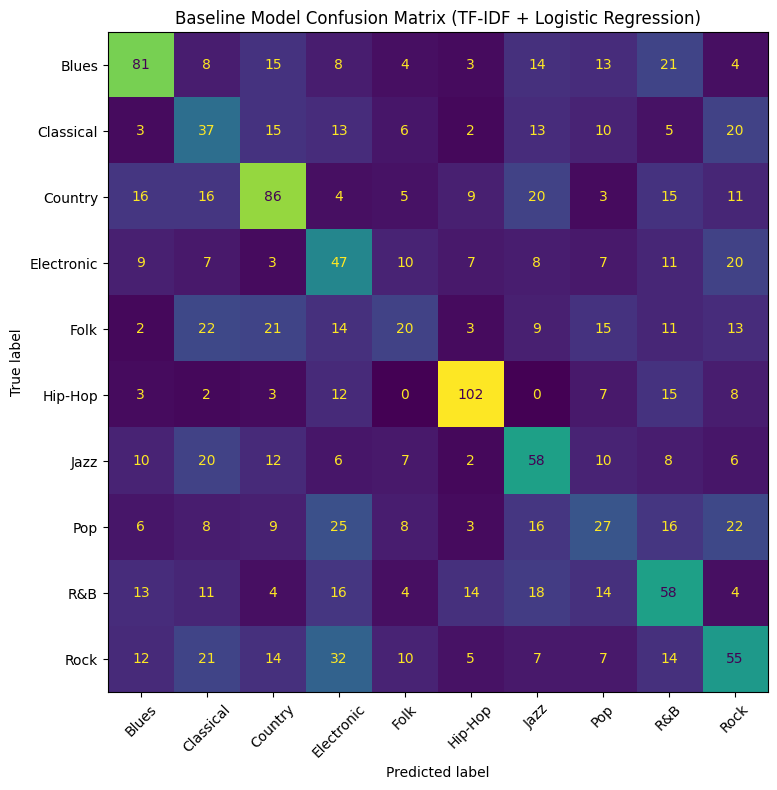

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# TF-IDF to convert each lyric into a vector of numbers
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_df['lyrics'])
X_val = vectorizer.transform(val_df['lyrics'])

y_train = train_df['genre']
y_val = val_df['genre']

# Train logistic regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
val_preds = clf.predict(X_val)
acc = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {acc:.4f}")

# Confusion matrix
genres = sorted(df_balanced['genre'].unique())
cm = confusion_matrix(y_val, val_preds, labels=genres)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genres)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Baseline Model Confusion Matrix (TF-IDF + Logistic Regression)')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# Save confusion matrix to Google Drive

import shutil
shutil.copy('baseline_confusion_matrix.png', '/content/drive/MyDrive/APS360_Project/baseline_confusion_matrix.png')

'/content/drive/MyDrive/APS360_Project/baseline_confusion_matrix.png'

#Primary Model

###Install and Load DistilBERT

In [ ]:
!pip install transformers -q

import torch
from transformers import DistilBertTokenizer, DistilBertModel
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Set up Dataset and Tokenizer

In [ ]:
from transformers import DistilBertTokenizer

# Label encoding
genres = sorted(df_balanced['genre'].unique())
genre2idx = {g: i for i, g in enumerate(genres)}
idx2genre = {i: g for g, i in genre2idx.items()}

print("Genre mapping:", genre2idx)

# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Dataset class
class LyricsDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.lyrics = df['lyrics'].tolist()
        self.labels = [genre2idx[g] for g in df['genre'].tolist()]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.lyrics)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.lyrics[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets and dataloaders
train_dataset = LyricsDataset(train_df, tokenizer)
val_dataset = LyricsDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Genre mapping: {'Blues': 0, 'Classical': 1, 'Country': 2, 'Electronic': 3, 'Folk': 4, 'Hip-Hop': 5, 'Jazz': 6, 'Pop': 7, 'R&B': 8, 'Rock': 9}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 439, Val batches: 94


## Define Model

In [ ]:
from transformers import DistilBertModel

class LyricsClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(LyricsClassifier, self).__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        output = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = output.last_hidden_state[:, 0, :]  # CLS token
        return self.classifier(cls_output)

model = LyricsClassifier(num_classes=10).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model parameters: 66,562,314


## Training Loop

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(3):
    # Training
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}/3 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {correct/total:.4f}")

Epoch 1/3 | Train Loss: 1.9775 | Val Loss: 1.8364 | Val Acc: 0.3693
Epoch 2/3 | Train Loss: 1.6212 | Val Loss: 1.6650 | Val Acc: 0.4365
Epoch 3/3 | Train Loss: 1.3496 | Val Loss: 1.7063 | Val Acc: 0.4318


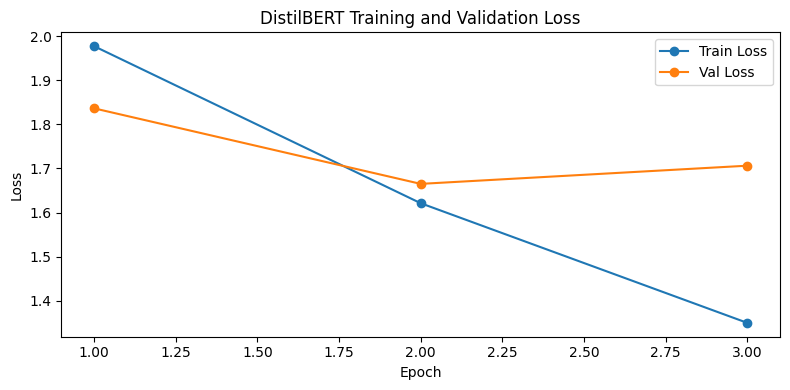

Song                                     True         Predicted    Correct
---------------------------------------------------------------------------
Stand And Deliver                        Blues        Rock         ✗
Chip on My Shoulder                      Classical    Classical    ✓
Indian Summer                            Country      Folk         ✗
Rio (feat. Digital Farm Animals)         Electronic   Electronic   ✓
Live Nude Cabaret                        Folk         Classical    ✗
Hammer Time (feat. Al Tariq, Problemz,   Hip-Hop      Hip-Hop      ✓
It Gonna Come - FKJ Remix                Jazz         Blues        ✗
He Knows My Name                         Pop          Pop          ✓
Young Love                               R&B          R&B          ✓
Is This Love - Live                      Rock         Pop          ✗


In [ ]:
# Plot loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 4), train_losses, label='Train Loss', marker='o')
ax.plot(range(1, 4), val_losses, label='Val Loss', marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('DistilBERT Training and Validation Loss')
ax.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

# Example predictions
model.eval()
examples = val_df.groupby('genre').first().reset_index()
print(f"{'Song':<40} {'True':<12} {'Predicted':<12} {'Correct'}")
print("-" * 75)
with torch.no_grad():
    for _, row in examples.iterrows():
        enc = tokenizer(row['lyrics'], max_length=256, padding='max_length',
                        truncation=True, return_tensors='pt')
        input_ids = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        output = model(input_ids, attention_mask)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs).item()
        pred_genre = idx2genre[pred_idx]
        correct = "Y" if pred_genre == row['genre'] else "N"
        print(f"{row['name'][:38]:<40} {row['genre']:<12} {pred_genre:<12} {correct}")

In [ ]:
import shutil
shutil.copy('loss_curve.png', '/content/drive/MyDrive/APS360_Project/loss_curve.png')
shutil.copy('baseline_confusion_matrix.png', '/content/drive/MyDrive/APS360_Project/baseline_confusion_matrix.png')
shutil.copy('class_distribution.png', '/content/drive/MyDrive/APS360_Project/class_distribution.png')

'/content/drive/MyDrive/APS360_Project/class_distribution.png'